# Proyecto 2 - Sistema de Ciberseguridad con IA

## Task 1: Configuración Segura de la Red (CSP)

### Task 1.1 Modelado

El problema se modela como un CSP (Constraint Satisfaction Problem):

**Variables:** Cada nodo del grafo representa un servidor. Hay entre 15 y 20 nodos. Cada variable $X_i$ corresponde al servidor $i$.

**Dominios:** Cada variable puede tomar uno de 4 protocolos de seguridad: `{Rojo, Verde, Azul, Amarillo}`.

**Restricciones (Factores):** Para cada arista $(X_i, X_j)$ en el grafo, el factor $f_{ij}$ exige que $X_i \neq X_j$. Esto evita vulnerabilidades de movimiento lateral entre servidores directamente conectados.

En el modelo de **Factor Graph**, los nodos de variable son los servidores y los nodos de factor representan cada restricción de adyacencia.

In [144]:
import random
import time
import copy

random.seed(42)

# Numero de nodos entre 15 y 20
NUM_NODOS = random.randint(15, 20)
COLORES = ["Rojo", "Verde", "Azul", "Amarillo"]

# Generar grafo aleatorio como lista de adyacencia
def generar_grafo(n, prob_arista=0.3):
    grafo = {i: set() for i in range(n)}
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < prob_arista:
                grafo[i].add(j)
                grafo[j].add(i)
    # Asegurar que el grafo sea conexo
    for i in range(1, n):
        if not grafo[i]:
            j = random.randint(0, i - 1)
            grafo[i].add(j)
            grafo[j].add(i)
    return grafo

GRAFO = generar_grafo(NUM_NODOS)

print(f"Grafo generado con {NUM_NODOS} nodos")
print(f"Dominio de colores: {COLORES}")
print("Lista de adyacencia:")
for nodo, vecinos in GRAFO.items():
    print(f"  Nodo {nodo}: {sorted(vecinos)}")

Grafo generado con 20 nodos
Dominio de colores: ['Rojo', 'Verde', 'Azul', 'Amarillo']
Lista de adyacencia:
  Nodo 0: [1, 3, 4, 5, 9, 10, 11, 18]
  Nodo 1: [0, 3, 5, 6, 8, 12, 13, 15, 17, 18]
  Nodo 2: [5, 6, 15]
  Nodo 3: [0, 1, 4, 7, 9, 12, 15, 19]
  Nodo 4: [0, 3, 8, 12, 13]
  Nodo 5: [0, 1, 2, 7, 11, 12, 18]
  Nodo 6: [1, 2, 9, 14, 15, 16]
  Nodo 7: [3, 5, 10, 14, 16]
  Nodo 8: [1, 4, 11, 15, 16, 18]
  Nodo 9: [0, 3, 6, 13, 16]
  Nodo 10: [0, 7]
  Nodo 11: [0, 5, 8, 12, 13, 14, 17, 19]
  Nodo 12: [1, 3, 4, 5, 11, 13, 14, 17]
  Nodo 13: [1, 4, 9, 11, 12, 17]
  Nodo 14: [6, 7, 11, 12, 15]
  Nodo 15: [1, 2, 3, 6, 8, 14, 16, 19]
  Nodo 16: [6, 7, 8, 9, 15, 19]
  Nodo 17: [1, 11, 12, 13, 18]
  Nodo 18: [0, 1, 5, 8, 17, 19]
  Nodo 19: [3, 11, 15, 16, 18]


### Task 1.2 Backtracking Puro

El **Backtracking Search** asigna valores a las variables una por una. Si en algún punto la asignación viola una restriccion, retrocede e intenta otro valor. No realiza ninguna inferencia anticipada.

In [145]:
def es_consistente(nodo, color, asignacion, grafo):
    # Verifica que ningun vecino ya asignado tenga el mismo color
    for vecino in grafo[nodo]:
        if vecino in asignacion and asignacion[vecino] == color:
            return False
    return True

def backtracking_puro(asignacion, nodos, grafo, colores, contador):
    # Caso base: todos los nodos asignados
    if len(asignacion) == len(nodos):
        return asignacion

    # Seleccionar el primer nodo no asignado
    nodo = next(n for n in nodos if n not in asignacion)

    for color in colores:
        contador[0] += 1
        if es_consistente(nodo, color, asignacion, grafo):
            asignacion[nodo] = color
            resultado = backtracking_puro(asignacion, nodos, grafo, colores, contador)
            if resultado is not None:
                return resultado
            del asignacion[nodo]
    return None

nodos = list(GRAFO.keys())
contador_puro = [0]
t0 = time.time()
solucion_pura = backtracking_puro({}, nodos, GRAFO, COLORES, contador_puro)
t1 = time.time()
tiempo_puro = t1 - t0

print("Backtracking puro - Solucion encontrada:")
for nodo, color in sorted(solucion_pura.items()):
    print(f"  Servidor {nodo}: {color}")
print(f"Asignaciones intentadas: {contador_puro[0]}")
print(f"Tiempo: {tiempo_puro:.6f} segundos")

Backtracking puro - Solucion encontrada:
  Servidor 0: Rojo
  Servidor 1: Verde
  Servidor 2: Rojo
  Servidor 3: Azul
  Servidor 4: Verde
  Servidor 5: Azul
  Servidor 6: Azul
  Servidor 7: Amarillo
  Servidor 8: Rojo
  Servidor 9: Amarillo
  Servidor 10: Verde
  Servidor 11: Verde
  Servidor 12: Amarillo
  Servidor 13: Rojo
  Servidor 14: Rojo
  Servidor 15: Amarillo
  Servidor 16: Verde
  Servidor 17: Azul
  Servidor 18: Amarillo
  Servidor 19: Rojo
Asignaciones intentadas: 1972
Tiempo: 0.001062 segundos


### Task 1.3 Forward Checking

El **Forward Checking** mejora el backtracking al propagar restricciones hacia adelante. Cuando se asigna un valor a una variable, se eliminan los valores incompatibles del dominio de sus vecinos no asignados. Si algún dominio queda vacío, se retrocede inmediatamente sin continuar.

In [146]:
def forward_checking(nodo, color, dominios, grafo):
    # Elimina el color asignado del dominio de los vecinos no asignados
    eliminados = []
    for vecino in grafo[nodo]:
        if color in dominios[vecino]:
            dominios[vecino].remove(color)
            eliminados.append(vecino)
            # Dominio vacio implica fallo
            if len(dominios[vecino]) == 0:
                return False, eliminados
    return True, eliminados

def restaurar_dominios(nodo_color, eliminados, dominios):
    # Restaura los dominios al deshacer una asignacion
    for vecino in eliminados:
        dominios[vecino].add(nodo_color)

print("Forward Checking implementado correctamente.")
print("Propaga restricciones al asignar un valor, eliminando valores incompatibles en vecinos.")

Forward Checking implementado correctamente.
Propaga restricciones al asignar un valor, eliminando valores incompatibles en vecinos.


### Task 1.4 Heurística MCV (Minimum Remaining Values)

La heurística **MCV** (o Variable más Restringida) selecciona siempre la variable con el menor numero de valores validos restantes en su dominio. Esto reduce el factor de ramificación del arbol de busqueda al tratar primero las variables con menos opciones, detectando fallos mas temprano.

In [147]:
def seleccionar_variable_mcv(asignacion, dominios):
    # Elige el nodo no asignado con el dominio mas pequeno (MCV)
    no_asignados = [n for n in dominios if n not in asignacion]
    return min(no_asignados, key=lambda n: len(dominios[n]))

print("Heuristica MCV implementada.")
print("Selecciona la variable con menor cantidad de valores validos restantes.")

Heuristica MCV implementada.
Selecciona la variable con menor cantidad de valores validos restantes.


### Task 1.5 Backtracking Optimizado (Forward Checking + MCV)

Se combinan Forward Checking y MCV para crear un backtracking eficiente: MCV escoge la variable mas critica y Forward Checking poda los dominios anticipadamente, evitando explorar ramas condenadas al fracaso.

In [148]:
def backtracking_optimizado(asignacion, dominios, grafo, colores, contador):
    # Todos los nodos asignados
    if len(asignacion) == len(grafo):
        return asignacion

    # Seleccion por MCV
    nodo = seleccionar_variable_mcv(asignacion, dominios)

    for color in list(dominios[nodo]):
        contador[0] += 1
        if es_consistente(nodo, color, asignacion, grafo):
            asignacion[nodo] = color

            # Forward checking: actualizar dominios de vecinos
            ok, eliminados = forward_checking(nodo, color, dominios, grafo)

            if ok:
                resultado = backtracking_optimizado(asignacion, dominios, grafo, colores, contador)
                if resultado is not None:
                    return resultado

            # Deshacer asignacion y restaurar dominios
            del asignacion[nodo]
            restaurar_dominios(color, eliminados, dominios)

    return None

# Inicializar dominios completos para cada nodo
dominios_iniciales = {nodo: set(COLORES) for nodo in GRAFO}
contador_opt = [0]
t2 = time.time()
solucion_opt = backtracking_optimizado({}, dominios_iniciales, GRAFO, COLORES, contador_opt)
t3 = time.time()
tiempo_opt = t3 - t2

print("Backtracking optimizado (FC + MCV) - Solucion encontrada:")
for nodo, color in sorted(solucion_opt.items()):
    print(f"  Servidor {nodo}: {color}")
print(f"Asignaciones intentadas: {contador_opt[0]}")
print(f"Tiempo: {tiempo_opt:.6f} segundos")

Backtracking optimizado (FC + MCV) - Solucion encontrada:
  Servidor 0: Rojo
  Servidor 1: Azul
  Servidor 2: Rojo
  Servidor 3: Amarillo
  Servidor 4: Azul
  Servidor 5: Amarillo
  Servidor 6: Amarillo
  Servidor 7: Verde
  Servidor 8: Rojo
  Servidor 9: Verde
  Servidor 10: Azul
  Servidor 11: Azul
  Servidor 12: Verde
  Servidor 13: Rojo
  Servidor 14: Rojo
  Servidor 15: Verde
  Servidor 16: Azul
  Servidor 17: Amarillo
  Servidor 18: Verde
  Servidor 19: Rojo
Asignaciones intentadas: 25
Tiempo: 0.000207 segundos


### Task 1.6 Analisis Comparativo

Se compara el rendimiento del Backtracking puro contra el Backtracking optimizado con Forward Checking y MCV, midiendo numero de asignaciones intentadas y tiempo de ejecucion.

In [149]:
print("Comparacion de rendimiento - Task 1")
print("-" * 45)
print(f"{'Metodo':<30} {'Asignaciones':>12} {'Tiempo (s)':>12}")
print(f"{'Backtracking puro':<30} {contador_puro[0]:>12} {tiempo_puro:>12.6f}")
print(f"{'Backtracking FC + MCV':<30} {contador_opt[0]:>12} {tiempo_opt:>12.6f}")
print("")

if contador_puro[0] > 0:
    reduccion = (1 - contador_opt[0] / contador_puro[0]) * 100
    print(f"Reduccion de asignaciones: {reduccion:.1f}%")
    
print("\nValidacion de solucion (sin conflictos entre vecinos):")
valido = True
for nodo, vecinos in GRAFO.items():
    for v in vecinos:
        if solucion_opt[nodo] == solucion_opt[v]:
            print(f"  CONFLICTO: Servidor {nodo} y Servidor {v} tienen el mismo protocolo")
            valido = False
if valido:
    print("Solucion valida: ningun par de servidores adyacentes comparte protocolo.")

Comparacion de rendimiento - Task 1
---------------------------------------------
Metodo                         Asignaciones   Tiempo (s)
Backtracking puro                      1972     0.001062
Backtracking FC + MCV                    25     0.000207

Reduccion de asignaciones: 98.7%

Validacion de solucion (sin conflictos entre vecinos):
Solucion valida: ningun par de servidores adyacentes comparte protocolo.


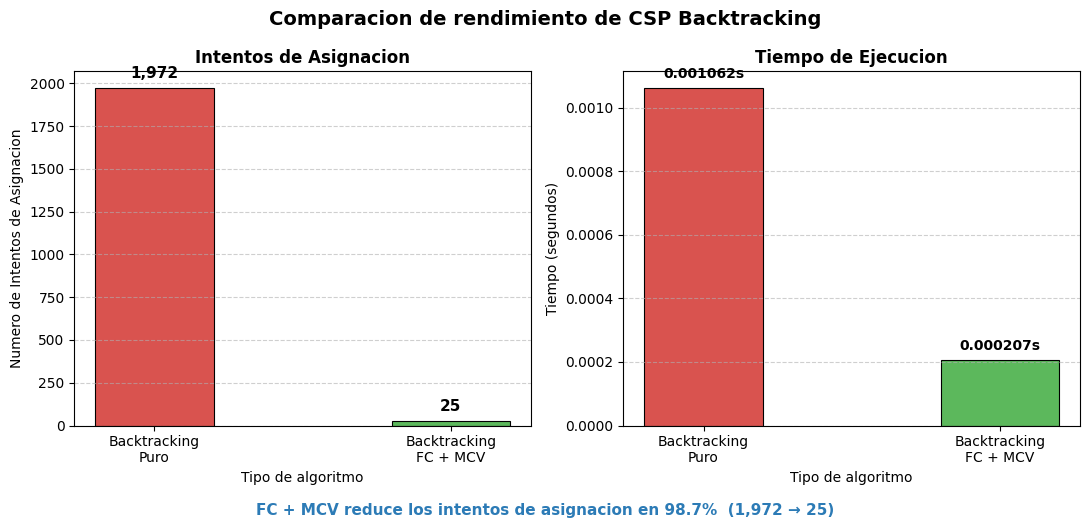

In [150]:
import matplotlib.pyplot as plt

methods_t1     = ['Backtracking\nPuro', 'Backtracking\nFC + MCV']
assignments_t1 = [contador_puro[0], contador_opt[0]]
times_t1       = [tiempo_puro, tiempo_opt]
colors_t1      = ['#d9534f', '#5cb85c']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('Comparacion de rendimiento de CSP Backtracking',
             fontsize=14, fontweight='bold')

ax1 = axes[0]
bars1 = ax1.bar(methods_t1, assignments_t1, color=colors_t1, edgecolor='black', linewidth=0.8, width=0.4)
ax1.set_title('Intentos de Asignacion', fontsize=12, fontweight='bold')
ax1.set_ylabel('Numero de Intentos de Asignacion')
ax1.set_xlabel('Tipo de algoritmo')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)
for bar, val in zip(bars1, assignments_t1):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(assignments_t1)*0.02,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2 = axes[1]
bars2 = ax2.bar(methods_t1, times_t1, color=colors_t1, edgecolor='black', linewidth=0.8, width=0.4)
ax2.set_title('Tiempo de Ejecucion', fontsize=12, fontweight='bold')
ax2.set_ylabel('Tiempo (segundos)')
ax2.set_xlabel('Tipo de algoritmo')
ax2.grid(True, axis='y', linestyle='--', alpha=0.6)
for bar, val in zip(bars2, times_t1):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(times_t1)*0.02,
             f'{val:.6f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

reduccion_t1 = (1 - contador_opt[0] / contador_puro[0]) * 100
fig.text(0.5, -0.03,
         f'FC + MCV reduce los intentos de asignacion en {reduccion_t1:.1f}%  '
         f'({contador_puro[0]:,} → {contador_opt[0]:,})',
         ha='center', fontsize=11, color='#2c7bb6', fontweight='bold')

plt.tight_layout()
plt.show()



- https://stackoverflow.com/questions/60161376/easiest-way-to-generate-an-undirected-graph-s-adjacency-list
- https://www.iquanta.in/blog/graph-coloring-explained-simply-with-examples-python-code/  

- https://www.freecodecamp.org/news/backtracking-algorithms-recursive-search/


## Task 2: Defensa Adversarial (Juegos de Suma Cero)

### Task 2.1 Modelado del Juego

Se reutiliza el grafo de la Task 1. A cada nodo se le asigna un **Valor de Informacion** (entero aleatorio). El juego es por turnos:
- **MAX (Defensa):** busca maximizar el valor total capturado.
- **MIN (Hacker):** busca minimizar el valor disponible para MAX.

En cada turno, el jugador activo puede capturar un nodo adyacente a los que ya controla. El juego termina cuando todos los nodos estan capturados o se alcanza el limite de turnos.

In [151]:
# Asignar valores de informacion aleatorios a cada nodo
random.seed(7)
VALORES = {nodo: random.randint(1, 20) for nodo in GRAFO}

print("Valores de informacion por servidor:")
for nodo, val in sorted(VALORES.items()):
    print(f"  Servidor {nodo}: {val}")

# Estado del juego: conjuntos de nodos capturados por MAX y MIN
# MAX inicia controlando el nodo 0, MIN inicia con el nodo opuesto
nodo_inicio_max = 0
nodo_inicio_min = NUM_NODOS - 1

estado_inicial = {
    "max": {nodo_inicio_max},
    "min": {nodo_inicio_min}
}

print(f"\nEstado inicial: MAX controla nodo {nodo_inicio_max}, MIN controla nodo {nodo_inicio_min}")

def movimientos_disponibles(capturados_jugador, capturados_rival, grafo):
    # Nodos adyacentes al jugador que no estan capturados por nadie
    ocupados = capturados_jugador | capturados_rival
    disponibles = set()
    for nodo in capturados_jugador:
        for vecino in grafo[nodo]:
            if vecino not in ocupados:
                disponibles.add(vecino)
    return disponibles

Valores de informacion por servidor:
  Servidor 0: 11
  Servidor 1: 5
  Servidor 2: 13
  Servidor 3: 2
  Servidor 4: 3
  Servidor 5: 18
  Servidor 6: 4
  Servidor 7: 12
  Servidor 8: 19
  Servidor 9: 2
  Servidor 10: 17
  Servidor 11: 7
  Servidor 12: 2
  Servidor 13: 3
  Servidor 14: 14
  Servidor 15: 14
  Servidor 16: 3
  Servidor 17: 8
  Servidor 18: 3
  Servidor 19: 18

Estado inicial: MAX controla nodo 0, MIN controla nodo 19


### Task 2.2 Minimax

El algoritmo **Minimax** busca la decision optima para MAX asumiendo que MIN tambien juega de forma optima. Se alterna entre capas MAX (maximizar) y MIN (minimizar). Se limita la profundidad a `d_max=4` y se usa una funcion de evaluacion heuristica para los estados no terminales.

In [152]:
D_MAX = 4

def eval_estado(capturados_max, capturados_min):
    # Eval(s) = suma de valores de MAX - suma de valores de MIN
    # Refleja la ventaja acumulada de la defensa sobre el atacante
    return sum(VALORES[n] for n in capturados_max) - sum(VALORES[n] for n in capturados_min)

def es_terminal(capturados_max, capturados_min):
    # Terminal si no hay mas movimientos para ninguno
    mov_max = movimientos_disponibles(capturados_max, capturados_min, GRAFO)
    mov_min = movimientos_disponibles(capturados_min, capturados_max, GRAFO)
    return len(mov_max) == 0 and len(mov_min) == 0

def minimax(cap_max, cap_min, profundidad, es_max, contador_mm):
    contador_mm[0] += 1

    # Condicion de corte: profundidad maxima o estado terminal
    if profundidad == 0 or es_terminal(cap_max, cap_min):
        return eval_estado(cap_max, cap_min)

    if es_max:
        movs = movimientos_disponibles(cap_max, cap_min, GRAFO)
        if not movs:
            # MAX sin movimientos: turno pasa a MIN
            return minimax(cap_max, cap_min, profundidad - 1, False, contador_mm)
        mejor = float("-inf")
        for nodo in movs:
            nueva_cap_max = cap_max | {nodo}
            val = minimax(nueva_cap_max, cap_min, profundidad - 1, False, contador_mm)
            mejor = max(mejor, val)
        return mejor
    else:
        movs = movimientos_disponibles(cap_min, cap_max, GRAFO)
        if not movs:
            # MIN sin movimientos: turno pasa a MAX
            return minimax(cap_max, cap_min, profundidad - 1, True, contador_mm)
        peor = float("inf")
        for nodo in movs:
            nueva_cap_min = cap_min | {nodo}
            val = minimax(cap_max, nueva_cap_min, profundidad - 1, True, contador_mm)
            peor = min(peor, val)
        return peor

contador_mm = [0]
t4 = time.time()
valor_mm = minimax(estado_inicial["max"], estado_inicial["min"], D_MAX, True, contador_mm)
t5 = time.time()

print(f"Minimax - Valor obtenido: {valor_mm}")
print(f"Nodos expandidos: {contador_mm[0]}")
print(f"Tiempo: {t5 - t4:.4f} segundos")

Minimax - Valor obtenido: -5
Nodos expandidos: 3135
Tiempo: 0.0080 segundos


### Task 2.3 Poda Alfa-Beta

La **Poda Alfa-Beta** optimiza Minimax eliminando ramas que no pueden influir en la decision final. `alpha` es el mejor valor que MAX puede garantizar y `beta` es el mejor que MIN puede garantizar. Cuando `alpha >= beta`, se poda la rama restante. La decision optima no cambia respecto a Minimax puro.

In [153]:
def minimax_ab(cap_max, cap_min, profundidad, es_max, alpha, beta, contador_ab):
    contador_ab[0] += 1

    if profundidad == 0 or es_terminal(cap_max, cap_min):
        return eval_estado(cap_max, cap_min)

    if es_max:
        movs = movimientos_disponibles(cap_max, cap_min, GRAFO)
        if not movs:
            return minimax_ab(cap_max, cap_min, profundidad - 1, False, alpha, beta, contador_ab)
        mejor = float("-inf")
        for nodo in movs:
            nueva_cap_max = cap_max | {nodo}
            val = minimax_ab(nueva_cap_max, cap_min, profundidad - 1, False, alpha, beta, contador_ab)
            mejor = max(mejor, val)
            alpha = max(alpha, mejor)
            # Poda beta: MIN no elegira este camino
            if alpha >= beta:
                break
        return mejor
    else:
        movs = movimientos_disponibles(cap_min, cap_max, GRAFO)
        if not movs:
            return minimax_ab(cap_max, cap_min, profundidad - 1, True, alpha, beta, contador_ab)
        peor = float("inf")
        for nodo in movs:
            nueva_cap_min = cap_min | {nodo}
            val = minimax_ab(cap_max, nueva_cap_min, profundidad - 1, True, alpha, beta, contador_ab)
            peor = min(peor, val)
            beta = min(beta, peor)
            # Poda alpha: MAX no elegira este camino
            if alpha >= beta:
                break
        return peor

contador_ab = [0]
t6 = time.time()
valor_ab = minimax_ab(estado_inicial["max"], estado_inicial["min"], D_MAX, True,
                       float("-inf"), float("inf"), contador_ab)
t7 = time.time()

print(f"Minimax con Poda Alfa-Beta - Valor obtenido: {valor_ab}")
print(f"Nodos expandidos: {contador_ab[0]}")
print(f"Tiempo: {t7 - t6:.4f} segundos")

Minimax con Poda Alfa-Beta - Valor obtenido: -5
Nodos expandidos: 836
Tiempo: 0.0032 segundos


### Task 2.4 Funcion de Evaluacion Eval(s)

La funcion heuristica `Eval(s)` estima el valor del estado sin llegar a nodos terminales:

$$Eval(s) = \sum_{n \in MAX} V(n) - \sum_{n \in MIN} V(n)$$

donde $V(n)$ es el Valor de Informacion del servidor $n$.

**Justificacion matematica:** Esta funcion es una buena aproximacion porque:
1. Es monotona: a mayor diferencia de valores capturados, mayor ventaja real de MAX.
2. Admisible: no sobreestima ni subestima sistematicamente el valor final.
3. Eficiente: se calcula en O(n) sin necesidad de explorar el arbol completo.

La función de evaluación definida como:

$$Eval(s) = \sum_{n \in MAX} valores - \sum_{n \in MIN} valores$$

es una aproximación del valor real de Minimax porque mide directamente la ventaja relativa entre ambos jugadores en un estado dado. Esta función preserva el orden de preferencia de los estados: si un estado tiene mayor diferencia a favor de MAX, entonces es considerado mejor.

Además, es consistente con el objetivo del juego, ya que MAX busca maximizar su ganancia total mientras MIN intenta minimizarla. Aunque no captura todas las posibles consecuencias futuras, proporciona una estimación razonable cuando la profundidad del árbol es limitada.

In [154]:
# Demostracion de la funcion Eval con el estado inicial
cap_max_demo = estado_inicial["max"]
cap_min_demo = estado_inicial["min"]

val_max = sum(VALORES[n] for n in cap_max_demo)
val_min = sum(VALORES[n] for n in cap_min_demo)
eval_inicial = eval_estado(cap_max_demo, cap_min_demo)

print("Funcion Eval(s) = suma_MAX - suma_MIN")
print(f"  Nodos MAX: {cap_max_demo} -> Suma = {val_max}")
print(f"  Nodos MIN: {cap_min_demo} -> Suma = {val_min}")
print(f"  Eval(s_inicial) = {val_max} - {val_min} = {eval_inicial}")

Funcion Eval(s) = suma_MAX - suma_MIN
  Nodos MAX: {0} -> Suma = 11
  Nodos MIN: {19} -> Suma = 18
  Eval(s_inicial) = 11 - 18 = -7


### Task 2.5 Analisis Comparativo Minimax vs Alfa-Beta

In [155]:
print("Comparacion de rendimiento")
print("-" * 50)
print(f"{'Metodo':<30} {'Nodos exp.':>10} {'Valor':>8}")
print(f"{'Minimax puro':<30} {contador_mm[0]:>10} {valor_mm:>8}")
print(f"{'Minimax + Alfa-Beta':<30} {contador_ab[0]:>10} {valor_ab:>8}")
print("")

if contador_mm[0] > 0:
    reduccion_nodos = (1 - contador_ab[0] / contador_mm[0]) * 100
    print(f"Reduccion de nodos expandidos: {reduccion_nodos:.1f}%")

print(f"\nAmbos algoritmos obtienen el mismo valor optimo ({valor_mm} == {valor_ab}): {valor_mm == valor_ab}")
print("La poda alfa-beta nunca altera la decision optima, solo elimina ramas irrelevantes.")

Comparacion de rendimiento
--------------------------------------------------
Metodo                         Nodos exp.    Valor
Minimax puro                         3135       -5
Minimax + Alfa-Beta                   836       -5

Reduccion de nodos expandidos: 73.3%

Ambos algoritmos obtienen el mismo valor optimo (-5 == -5): True
La poda alfa-beta nunca altera la decision optima, solo elimina ramas irrelevantes.


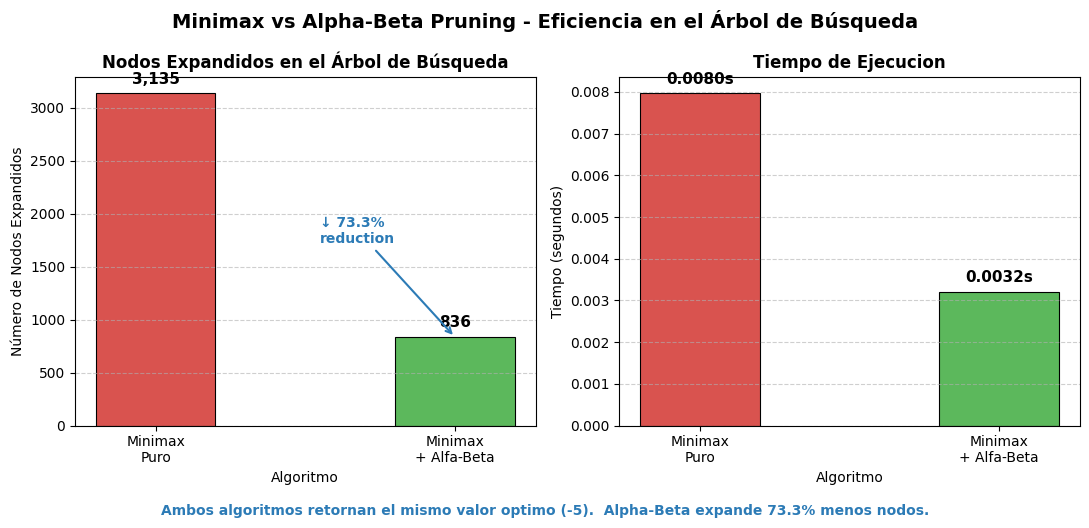

In [156]:
import matplotlib.pyplot as plt

reduccion_ab = (1 - contador_ab[0] / contador_mm[0]) * 100
methods_t2   = ['Minimax\nPuro', 'Minimax\n+ Alfa-Beta']
nodes_t2     = [contador_mm[0], contador_ab[0]]
times_t2     = [t5 - t4, t7 - t6]
colors_t2    = ['#d9534f', '#5cb85c']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('Minimax vs Alpha-Beta Pruning - Eficiencia en el Árbol de Búsqueda',
             fontsize=14, fontweight='bold')

# Bar 1: Nodes expanded
ax1 = axes[0]
bars1 = ax1.bar(methods_t2, nodes_t2, color=colors_t2, edgecolor='black', linewidth=0.8, width=0.4)
ax1.set_title('Nodos Expandidos en el Árbol de Búsqueda', fontsize=12, fontweight='bold')
ax1.set_ylabel('Número de Nodos Expandidos')
ax1.set_xlabel('Algoritmo')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)
for bar, val in zip(bars1, nodes_t2):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(nodes_t2)*0.02,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.annotate(f'↓ {reduccion_ab:.1f}%\nreduction',
             xy=(1, contador_ab[0]), xytext=(0.55, contador_mm[0]*0.55),
             fontsize=10, color='#2c7bb6', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#2c7bb6', lw=1.5))

# Bar 2: Execution time
ax2 = axes[1]
bars2 = ax2.bar(methods_t2, times_t2, color=colors_t2, edgecolor='black', linewidth=0.8, width=0.4)
ax2.set_title('Tiempo de Ejecucion', fontsize=12, fontweight='bold')
ax2.set_ylabel('Tiempo (segundos)')
ax2.set_xlabel('Algoritmo')
ax2.grid(True, axis='y', linestyle='--', alpha=0.6)
for bar, val in zip(bars2, times_t2):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(times_t2)*0.02,
             f'{val:.4f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

fig.text(0.5, -0.03,
         f'Ambos algoritmos retornan el mismo valor optimo ({valor_mm}).  '
         f'Alpha-Beta expande {reduccion_ab:.1f}% menos nodos.',
         ha='center', fontsize=10, color='#2c7bb6', fontweight='bold')

plt.tight_layout()
plt.show()


- https://www.geeksforgeeks.org/dsa/minimax-algorithm-in-game-theory-set-1-introduction/

- https://ocw.mit.edu/courses/6-034-artificial-intelligence-fall-2010/resources/lecture-6-search-games-minimax-and-alpha-beta/
- https://cs50.harvard.edu/ai/notes/3/
- https://uvg.instructure.com/courses/43786/pages/semana-9-juegos-i?module_item_id=1392609 (Presentación S9 - Juegos I)

## Task 3: Incertidumbre y Latencia (Expectiminimax y MDPs)

### Task 3.1 Expectiminimax con Nodos de Azar

En el mundo real, las acciones no siempre tienen el resultado esperado. Se introduce un **nodo de azar** (chance node) despues de cada decision:

- Con probabilidad **0.80**: la captura tiene exito (el nodo se agrega al jugador).
- Con probabilidad **0.20**: la accion falla y el turno se pierde sin cambios.

El valor de un nodo de azar es la esperanza matematica: $V_{chance} = 0.8 \cdot V_{exito} + 0.2 \cdot V_{fallo}$

El algoritmo Expectiminimax extiende Minimax para manejar entornos estocásticos donde las acciones no siempre tienen resultados deterministas. En este modelo, además de nodos MAX y MIN, se introducen nodos de azar (chance nodes).

Después de cada acción, el resultado no es seguro, sino que depende de una distribución de probabilidad. En este caso, una acción tiene un 80% de probabilidad de éxito y un 20% de probabilidad de fallo.

En lugar de elegir el máximo o mínimo directamente, los nodos de azar calculan el valor esperado:


$$E(s) = \sum_{i} P(s_i) \cdot V(s_i)$$


Esto hace que el agente no solo considere el mejor resultado posible, sino también el riesgo asociado a cada acción. Como consecuencia, Expectiminimax tiende a tomar decisiones más conservadoras, evitando acciones con alta incertidumbre negativa, a diferencia de Minimax que asume un entorno completamente determinista.

In [ ]:
P_EXITO = 0.8
P_FALLO = 0.2

def expectiminimax(cap_max, cap_min, profundidad, turno, contador_emm):
    contador_emm[0] += 1

    if profundidad == 0 or es_terminal(cap_max, cap_min):
        return eval_estado(cap_max, cap_min)

    if turno == "max":
        movs = movimientos_disponibles(cap_max, cap_min, GRAFO)
        if not movs:
            return expectiminimax(cap_max, cap_min, profundidad - 1, "min", contador_emm)
        mejor = float("-inf")
        for nodo in movs:
            # Despues de la decision de MAX, viene el nodo de azar
            val = expectiminimax(cap_max, cap_min, profundidad, "chance_max",
                                  contador_emm) if False else _chance_max(cap_max, cap_min, nodo, profundidad, contador_emm)
            mejor = max(mejor, val)
        return mejor

    elif turno == "min":
        movs = movimientos_disponibles(cap_min, cap_max, GRAFO)
        if not movs:
            return expectiminimax(cap_max, cap_min, profundidad - 1, "max", contador_emm)
        peor = float("inf")
        for nodo in movs:
            val = _chance_min(cap_max, cap_min, nodo, profundidad, contador_emm)
            peor = min(peor, val)
        return peor

def _chance_max(cap_max, cap_min, nodo_elegido, profundidad, contador_emm):
    # Nodo de azar para MAX: 80% captura, 20% falla
    val_exito = expectiminimax(cap_max | {nodo_elegido}, cap_min,
                                profundidad - 1, "min", contador_emm)
    # Si falla, el estado no cambia y el turno pasa a MIN
    val_fallo = expectiminimax(cap_max, cap_min,
                                profundidad - 1, "min", contador_emm)
    return P_EXITO * val_exito + P_FALLO * val_fallo

def _chance_min(cap_max, cap_min, nodo_elegido, profundidad, contador_emm):
    # Nodo de azar para MIN: 80% captura, 20% falla
    val_exito = expectiminimax(cap_max, cap_min | {nodo_elegido},
                                profundidad - 1, "max", contador_emm)
    val_fallo = expectiminimax(cap_max, cap_min,
                                profundidad - 1, "max", contador_emm)
    return P_EXITO * val_exito + P_FALLO * val_fallo

# Redefinir expectiminimax para usar las funciones de chance correctamente
def expectiminimax(cap_max, cap_min, profundidad, turno, contador_emm):
    contador_emm[0] += 1

    if profundidad == 0 or es_terminal(cap_max, cap_min):
        return eval_estado(cap_max, cap_min)

    if turno == "max":
        movs = movimientos_disponibles(cap_max, cap_min, GRAFO)
        if not movs:
            return expectiminimax(cap_max, cap_min, profundidad - 1, "min", contador_emm)
        mejor = float("-inf")
        for nodo in movs:
            # Nodo de azar para MAX
            val_exito = expectiminimax(cap_max | {nodo}, cap_min,
                                        profundidad - 1, "min", contador_emm)
            val_fallo = expectiminimax(cap_max, cap_min,
                                        profundidad - 1, "min", contador_emm)
            val_esperado = P_EXITO * val_exito + P_FALLO * val_fallo
            mejor = max(mejor, val_esperado)
        return mejor

    else:  # turno == "min"
        movs = movimientos_disponibles(cap_min, cap_max, GRAFO)
        if not movs:
            return expectiminimax(cap_max, cap_min, profundidad - 1, "max", contador_emm)
        peor = float("inf")
        for nodo in movs:
            # Nodo de azar para MIN
            val_exito = expectiminimax(cap_max, cap_min | {nodo},
                                        profundidad - 1, "max", contador_emm)
            val_fallo = expectiminimax(cap_max, cap_min,
                                        profundidad - 1, "max", contador_emm)
            val_esperado = P_EXITO * val_exito + P_FALLO * val_fallo
            peor = min(peor, val_esperado)
        return peor

contador_emm = [0]
t8 = time.time()
valor_emm = expectiminimax(estado_inicial["max"], estado_inicial["min"], D_MAX, "max", contador_emm)
t9 = time.time()

print(f"Expectiminimax - Valor esperado: {valor_emm:.4f}")
print(f"Nodos expandidos: {contador_emm[0]}")
print(f"Tiempo: {t9 - t8:.4f} segundos")

### Task 3.2 Simulacion: Minimax vs Aleatorio / Expectiminimax vs Aleatorio

Se simulan partidas completas en el entorno con fallos para comparar el comportamiento de ambos agentes inteligentes contra un agente aleatorio.

In [ ]:
def agente_aleatorio_mover(capturados_jugador, capturados_rival, grafo):
    # Elige aleatoriamente entre los movimientos disponibles
    movs = list(movimientos_disponibles(capturados_jugador, capturados_rival, grafo))
    if not movs:
        return None
    return random.choice(movs)

def mejor_movimiento_minimax(cap_max, cap_min, profundidad):
    # Devuelve el nodo que maximiza el valor minimax
    movs = list(movimientos_disponibles(cap_max, cap_min, GRAFO))
    if not movs:
        return None
    mejor_val = float("-inf")
    mejor_nodo = movs[0]
    for nodo in movs:
        c = [0]
        val = minimax_ab(cap_max | {nodo}, cap_min, profundidad - 1, False,
                         float("-inf"), float("inf"), c)
        if val > mejor_val:
            mejor_val = val
            mejor_nodo = nodo
    return mejor_nodo

def mejor_movimiento_emm(cap_max, cap_min, profundidad):
    # Devuelve el nodo que maximiza el valor esperado de Expectiminimax
    movs = list(movimientos_disponibles(cap_max, cap_min, GRAFO))
    if not movs:
        return None
    mejor_val = float("-inf")
    mejor_nodo = movs[0]
    for nodo in movs:
        c = [0]
        val_exito = expectiminimax(cap_max | {nodo}, cap_min, profundidad - 1, "min", c)
        val_fallo = expectiminimax(cap_max, cap_min, profundidad - 1, "min", c)
        val_esp = P_EXITO * val_exito + P_FALLO * val_fallo
        if val_esp > mejor_val:
            mejor_val = val_esp
            mejor_nodo = nodo
    return mejor_nodo

def simular_partida(agente_max_fn, num_turnos=20):
    # Simula una partida con fallos probabilisticos
    cap_max = {nodo_inicio_max}
    cap_min = {nodo_inicio_min}
    turno = "max"

    for _ in range(num_turnos):
        if es_terminal(cap_max, cap_min):
            break

        if turno == "max":
            nodo = agente_max_fn(cap_max, cap_min)
            if nodo is not None:
                # Aplicar probabilidad de fallo
                if random.random() < P_EXITO:
                    cap_max.add(nodo)
            turno = "min"
        else:
            nodo = agente_aleatorio_mover(cap_min, cap_max, GRAFO)
            if nodo is not None:
                if random.random() < P_EXITO:
                    cap_min.add(nodo)
            turno = "max"

    return eval_estado(cap_max, cap_min), len(cap_max), len(cap_min)

NUM_SIMULACIONES = 30
random.seed(99)

# Agente Minimax vs Aleatorio
resultados_mm = [simular_partida(lambda c_max, c_min: mejor_movimiento_minimax(c_max, c_min, 3))
                  for _ in range(NUM_SIMULACIONES)]
# Agente Expectiminimax vs Aleatorio
resultados_emm = [simular_partida(lambda c_max, c_min: mejor_movimiento_emm(c_max, c_min, 3))
                   for _ in range(NUM_SIMULACIONES)]

puntos_mm = [r[0] for r in resultados_mm]
nodos_max_mm = [r[1] for r in resultados_mm]

puntos_emm = [r[0] for r in resultados_emm]
nodos_max_emm = [r[1] for r in resultados_emm]

print(f"Simulacion: {NUM_SIMULACIONES} partidas por agente")
print("-" * 55)
print(f"{'Metodo':<30} {'Punt. prom.':>12} {'Nodos prom.':>12}")
print(f"{'Minimax vs Aleatorio':<30} {sum(puntos_mm)/len(puntos_mm):>12.2f} {sum(nodos_max_mm)/len(nodos_max_mm):>12.2f}")
print(f"{'Expectiminimax vs Aleatorio':<30} {sum(puntos_emm)/len(puntos_emm):>12.2f} {sum(nodos_max_emm)/len(nodos_max_emm):>12.2f}")

In [ ]:
import matplotlib.pyplot as plt

avg_mm  = sum(puntos_mm)  / len(puntos_mm)
avg_emm = sum(puntos_emm) / len(puntos_emm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Minimax vs Expectiminimax - 30 Simulaciones en Ambiente Estocástico (20% Fallo)',
             fontsize=13, fontweight='bold')

# Bar chart: Average scores
ax1 = axes[0]
labels_t3 = ['Minimax\nvs Random', 'Expectiminimax\nvs Random']
avgs_t3   = [avg_mm, avg_emm]
colors_t3 = ['#d9534f', '#5bc0de']
bars1 = ax1.bar(labels_t3, avgs_t3, color=colors_t3, edgecolor='black',
                linewidth=0.8, width=0.4)
ax1.set_title('Promedio de Puntuación en 30 Simulaciones', fontsize=12, fontweight='bold')
ax1.set_ylabel('Promedio de Puntuación  (MAX value − MIN value)')
ax1.set_xlabel('Agente')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)
for bar, val in zip(bars1, avgs_t3):
    offset = max(avgs_t3)*0.03 if val >= 0 else min(avgs_t3)*0.03
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + offset,
             f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Line plot: per-simulation score trend
ax2 = axes[1]
sims = list(range(1, NUM_SIMULACIONES + 1))
ax2.plot(sims, puntos_mm,  color='#d9534f', linewidth=1.5, marker='o', markersize=4,
         label=f'Minimax (avg={avg_mm:.2f})')
ax2.plot(sims, puntos_emm, color='#5bc0de', linewidth=1.5, marker='s', markersize=4,
         label=f'Expectiminimax (avg={avg_emm:.2f})')
ax2.axhline(avg_mm,  color='#d9534f', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(avg_emm, color='#5bc0de', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_title('Puntuación por Simulación – Comparación de Tendencias', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de Simulación')
ax2.set_ylabel('Puntuación')
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.6)

fig.text(0.5, -0.03,
         'Expectiminimax considera la probabilidad de fallo del 20%, '
         'tomando decisiones más conservadoras y ajustadas al riesgo que el Minimax puro.',
         ha='center', fontsize=10, color='#2c7bb6', fontweight='bold')

plt.tight_layout()
plt.show()


### Task 3.3 Analisis: Diferencias de Comportamiento

**Minimax puro** asume que todas las acciones tienen exito. En un entorno con un 20% de probabilidad de fallo, este agente puede comportarse de forma excesivamente agresiva: elige movimientos de alto valor asumiendo que siempre se ejecutaran, pero en la practica sufre mas fallos en acciones criticas.

**Expectiminimax** incorpora explicitamente la incertidumbre al calcular el valor esperado en los nodos de azar: $V = 0.8 \cdot V_{exito} + 0.2 \cdot V_{fallo}$. Esto lo hace mas **conservador**: prefiere movimientos robustos cuyo valor esperado sea alto incluso si fallan, en lugar de apostar todo a un movimiento de maximo valor que podria no concretarse.

El resultado es que Expectiminimax tiende a capturar nodos de valor moderado pero con alta probabilidad de exito acumulado, en lugar de perseguir siempre el maximo valor inmediato.